## LangGraph Node

**Nodes** are the fundamental building blocks of a LangGraph application. Each node represents a single unit of work or processing step in your workflow.

### Key Characteristics:
- **Function-based**: A node is essentially a Python function that processes state
- **Input/Output**: Takes the current `AgentState` as input and returns an updated `AgentState`
- **Stateful**: Nodes can read from and write to the shared state object
- **Reusable**: The same node can be used multiple times in a graph


In [ ]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph # framework that helps you design and manage the flow of tasks in your application using a graph structure

In [ ]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs. 

class AgentState(TypedDict): # Our state schema
    message : str 


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state["message"] + ", how is your day going?"

    return state 

In [10]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

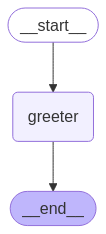

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"message": "Bob"})

In [13]:
result["message"]

'Hey Bob, how is your day going?'

## 2. Handling Multiple Inputs

### Concept:
Instead of just one input field, the `AgentState` can contain multiple attributes (like `values`, `name`, `result`), and a single node can access and process all of them at once.

### Key Features:
- **Multiple State Fields**: State schema includes `List[int]`, `str`, and other types
- **Single Processing Node**: One node can read multiple inputs and produce output
- **Flexible State Access**: Nodes can access any field from the state dictionary

### Use Case:
This pattern is useful when you need to:
- Aggregate data from multiple sources
- Perform calculations on different data types
- Combine various inputs into a single output

In [4]:
from typing import TypedDict, List
from langgraph.graph import StateGraph 

In [5]:
class AgentState(TypedDict):
    values: List[int]
    name: str 
    result: str 

In [14]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)

    state["result"] = f"Hi there {state["name"]}! Your sum = {sum(state["values"])}"

    print(state)
    return state

In [15]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor") # Set the starting node
graph.set_finish_point("processor") # Set the ending node

app = graph.compile() # Compiling the graph

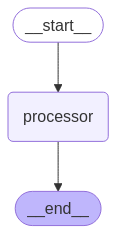

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve"})

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [13]:
print(answers["result"])

Hi there Steve! Your sum = 10


## 3. Sequential Agent Workflow

### Concept:
Sequential workflows allow you to chain multiple processing steps together, where each node's output becomes the input for the next node in the sequence.

### Key Components:

#### **1. Multiple Nodes**
- `first_node`: Performs initial processing
- `second_node`: Continues processing from where the first node left off

#### **2. Edge Connections**
Using `add_edge()` to create a direct connection between nodes:
```python
graph.add_edge("first_node", "second_node")
```

#### **3. Entry and Exit Points**
```python
set_entry_point("first_node"): Defines where execution starts
set_finish_point("second_node"): Defines where execution ends
```

In [3]:
from typing import TypedDict # Imports all the data types we need
from langgraph.graph import StateGraph

In [4]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [9]:
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state["name"]}!"
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state["final"] = state["final"] + f" You are {state["age"]} years old!"

    return state

In [10]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

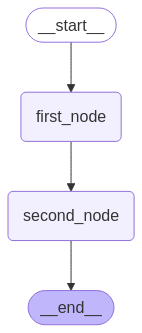

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
result = app.invoke({"name": "Charlie", "age": 20})
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old!'}


## 4. Conditional Agent Workflow

### Concept:
Instead of following a fixed path, conditional workflows use decision functions to route execution to different nodes based on specific conditions.

### Key Components:

#### **1. Router/Decision Function**
A function that examines the state and returns a string indicating which path to take:
```python
def decide_next_node(state: AgentState) -> str:
    if condition:
        return "path_a"
    else:
        return "path_b"
```

#### **2. Conditional Edges**
Using add_conditional_edges() to create dynamic routing:
```python
graph.add_conditional_edges(
    "source_node",      # Starting point
    decision_function,  # Function that decides the path
    {
        "path_a": "node_a",  # Mapping of return values to nodes
        "path_b": "node_b"
    }
)
```
#### **3. Execution flow**

    `START → router → [decision] → add_node OR subtract_node → END`
                        ↓                ↓
                `(if "+")        (if "-")`


### Use Cases:
- If-else logic: Route based on conditions
- Task routing: Direct work to specialized processors
- Validation flows: Different paths for valid/invalid data
- Multi-option workflows: Handle multiple scenarios dynamically
### Advantages:
- Flexibility: Execution path determined at runtime
- Scalability: Easy to add more conditional branches
- Clean separation: Each branch handles specific logic

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    finalNumber: int

In [3]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation" 



In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router") 

graph.add_conditional_edges(
    "router",
    decide_next_node, 

    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }

)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

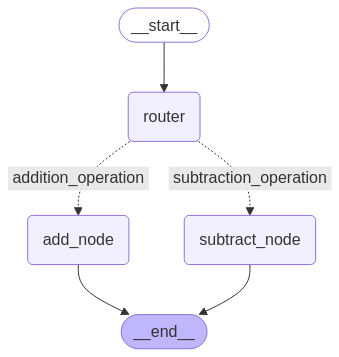

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


In [ ]:
# This way still works!

result = app.invoke({"number1": 10, "operation": "-", "number2": 5})
print(result)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


## 5. Looping in LangGraph

### Concept:
Looping allows a graph to **repeatedly execute the same node** until a specific condition is met. This enables iterative processing, retry logic, and recursive behaviors in your workflows.

### Key Components:

#### 1. Counter/State Tracker
A state variable that tracks iterations:
```python
class AgentState(TypedDict):
    counter: int  # Tracks loop iterations
    # other fields...
```
#### 2. Loop Control Function
A decision function that determines whether to continue looping or exit:
```python
def should_continue(state: AgentState) -> str:
    if state["counter"] < max_iterations:
        return "loop"  # Continue looping
    else:
        return "exit"  # Exit the loop
```

#### 3. Self-Referencing Edge
Using add_conditional_edges() where a node can point back to itself:
```python
graph.add_conditional_edges(
    "node_name",
    should_continue,
    {
        "loop": "node_name",  # Points back to itself
        "exit": END           # Exits the graph
    }
)
```

#### Execution flow
    `
    START → greeting → random → [decision]
                      ↑          |
                      |         [continue?]
                      +---------+    |
                                    [exit]
                                     ↓
                                    END
    `

#### Loop Pattern:
- Initialization: Set counter to 0 in the first node
- Processing: Execute logic in the loop node
- Increment: Update counter in the loop node
- Decision: Check condition and decide to loop or exit
- Repeat: If looping, go back to step 2

#### Use Cases:
- Iterative refinement: Improve results over multiple passes
- Retry logic: Retry failed operations with backoff
- Batch processing: Process items until queue is empty
- Convergence: Run until a condition converges
- Data generation: Generate multiple items (e.g., random numbers)


In [3]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [4]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [5]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0 

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state["number"].append(random.randint(0, 10))
    state["counter"] += 1

    return state


def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop"  # Continue looping
    else:
        return "exit"  # Exit the loop
    

In [ ]:
# greeting → random → random → random → random → random → END

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")


graph.add_conditional_edges(
    "random",     # Source node
    should_continue, # Action
    {
        "loop": "random",  
        "exit": END          
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

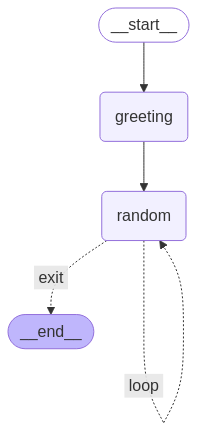

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
app.invoke({"name":"Vaibhav", "number":[], "counter":-100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Vaibhav', 'number': [3, 0, 1, 9, 5], 'counter': 5}